# The Hello World of Deep Learning with Neural Networks

Like every first app, you should start with something super simple that shows the overall scaffolding for how your code works. In the case of creating neural networks, one simple case is where it learns the relationship between two numbers. So, for example, if you were writing code for a function like this, you already know the 'rules':

> Add blockquote




```
def hw_function(x):
    y = (2 * x) - 1
    return y
```

So how would you train a neural network to do the equivalent task? By using data! By feeding it with a set of x's and y's, it should be able to figure out the relationship between them.

This is obviously a very different paradigm from what you might be used to. So let's step through it piece by piece.


## Imports

Start with the imports. Here, you are importing [TensorFlow](https://www.tensorflow.org/) and calling it `tf` for convention and ease of use.
The framework you will use to build a neural network as a sequence of layers is called [`keras`](https://keras.io/) and is contained within tensorflow, so you can access it using `tf.keras`.

You then import a library called [`numpy`](https://numpy.org) which helps to represent data as arrays easily and to optimize numerical operations.

In [ ]:
import tensorflow as tf
import numpy as np

## Generating the Data

Before creating a neural network you will generate the data that you will be working with. In this case, you are taking 6 X's and 6 Y's. You can see that the relationship between these is `y=2x-1`, so where Case1 : `x=-1`, `y=-3`  , Case2 : `x=0`, `y=-1`,  etc.

The standard way of declaring model inputs and outputs is to use `numpy`, a Python library that provides lots of array type data structures.
  

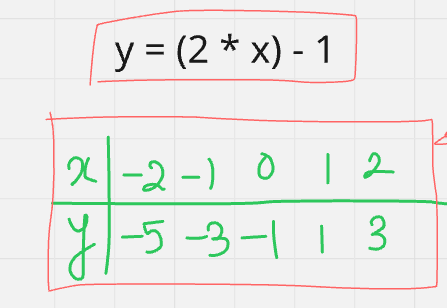

In [ ]:
# Here we are declaring model inputs and outputs for training
xs = np.array([-1.0,  0.0, 1.0, 2.0, 3.0, 4.0, -2.0], dtype=float)
ys = np.array([-3.0, -1.0, 1.0, 3.0, 5.0, 7.0 , -5.0], dtype=float)

## Define and Compile the Neural Network

Next, you will create the simplest possible neural network. It has **1 layer with 1 neuron**. You will build this model using Keras' [Sequential](https://keras.io/api/models/sequential/) class which allows you to define the network as a sequence of [layers](https://keras.io/api/layers/). You can use a single [Dense](https://keras.io/api/layers/core_layers/dense/) layer to build this simple network.

It is good practice to define the expected shape of the input to the model. In this case, you see that each element in `xs` is a scalar, which you can also treat as a 1-dimensional vector. You can define this shape through the [tf.keras.Input()](https://www.tensorflow.org/api_docs/python/tf/keras/Input) object and its `shape` parameter as shown below. Take note that this is not a layer so even if there are two lines of code inside `Sequential` below, this is still a one-layer model.

In [ ]:
# building a simple sequential model
# model = tf.keras.Sequential([ tf.keras.Input(shape=(1,)),tf.keras.layers.Dense(units=1)])

model = tf.keras.Sequential([

    # Define the input shape
    tf.keras.Input(shape=(1,)),

    # Add a Dense layer
    tf.keras.layers.Dense(units=1)
    ])

# first way
# model = tf.keras.Sequential([ tf.keras.Input(shape=(1,)),tf.keras.layers.Dense(units=1)])
# #second way to write
# model = keras.Sequential()
# model.add(keras.Input(shape=(16,)))
# model.add(keras.layers.Dense(8))

Now, you will compile the neural network. When you do so, you have to specify 2 functions: a [loss](https://keras.io/api/losses/) and an [optimizer](https://keras.io/api/optimizers/).

If you've seen lots of math for machine learning, here's where it's usually used. But in this case, it's nicely encapsulated in functions and classes for you. But what happens here?

You know that in the function declared at the start of this notebook, the relationship between the numbers is `y=2x-1`. When the computer is trying to 'learn' that, it makes a guess... maybe `y=10x+10`. The `loss` function measures the guessed answers against the known correct answers and measures how well or how badly it did.

It then uses the `optimizer` function to make another guess. Based on how the loss function went, it will try to minimize the loss. At that point maybe it will come up with something like `y=5x+5`, which, while still pretty bad, is closer to the correct result (i.e. the loss is lower).

It will repeat this for the number of _epochs_ which you will see shortly. But first, here's how you will tell it to use [mean squared error](https://keras.io/api/losses/regression_losses/#meansquarederror-function) for the loss and [stochastic gradient descent](https://keras.io/api/optimizers/sgd/) for the optimizer. You don't need to understand the math for these yet, but you can see that they work!

Over time, you will learn the different and appropriate loss and optimizer functions for different scenarios.


In [ ]:
# Compile the model
model.compile(optimizer='sgd', loss='mean_squared_error')
# model.compil

# Training the Neural Network

The process of training the neural network, where it 'learns' the relationship between the x's and y's is in the [`model.fit()`](https://keras.io/api/models/model_training_apis/#fit-method)  call. This is where it will go through the loop we spoke about above: making a guess, measuring how good or bad it is (aka the loss), using the optimizer to make another guess etc. It will do it for the number of `epochs` you specify. When you run this code, you'll see the loss on the right hand side.

### Epoch 10

In [ ]:
# Step 1 :
# Build a simple Sequential model
model10 = tf.keras.Sequential([

    # Define the input shape
    tf.keras.Input(shape=(1,)),

    # Add a Dense layer
    tf.keras.layers.Dense(units=1)
    ])

In [ ]:
# Step 2
# Compile the model
model10.compile(optimizer='sgd', loss='mean_squared_error')

In [ ]:
# Step 3: Train the model
model10.fit(xs, ys, epochs=10)

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step - loss: 40.0961
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 32.4933
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 26.3888
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 21.4854
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 17.5451
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 14.3770
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 11.8282
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 9.7760
Epoch 9/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 8.1222
Epoch 10/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 6.7879


Ok, now we have a model that has been trained to learn the relationship between `x` and `y`. You can use the [`model.predict()`](https://keras.io/api/models/model_training_apis/#predict-method) method to have it figure out the `y` for a previously unknown `x`. So, for example, if `x=10`, what do you think `y` will be? Take a guess before you run this code:

In [ ]:
# Make a prediction
print(f"model predicted: {model10.predict(np.array([10.0]), verbose=0).item():.5f}")

model predicted: 8.23541


You might have thought `19`, right? But it ended up being a little under. Why do you think that is?

Remember that neural networks deal with probabilities. So given the data that we fed the model with, it calculated that there is a very high probability that the relationship between `x` and `y` is `y=2x-1`, but with only 6 data points we can't know for sure. As a result, the result for 10 is very close to 19, but not necessarily 19.

As you work with neural networks, you'll see this pattern recurring. You will almost always deal with probabilities, not certainties, and will do a little bit of coding to figure out what the result is based on the probabilities, particularly when it comes to classification.


### Epoch 20

In [ ]:
# Step 1 :
# Build a simple Sequential model
model20 = tf.keras.Sequential([

    # Define the input shape
    tf.keras.Input(shape=(1,)),

    # Add a Dense layer
    tf.keras.layers.Dense(units=1)
    ])

In [ ]:
# Step 2
# Compile the model
model20.compile(optimizer='sgd', loss='mean_squared_error')

In [ ]:
# Train the model
model20.fit(xs, ys, epochs=20)

Epoch 1/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - loss: 13.2964
Epoch 2/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 10.9029
Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 8.9770
Epoch 4/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 7.4261
Epoch 5/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 6.1760
Epoch 6/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 5.1673
Epoch 7/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 4.3522
Epoch 8/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 3.6924
Epoch 9/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 3.1575
Epoch 10/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 2.7227
Epoch 11/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 2.3684
Epoch 12/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 2.0787
Epoch 13/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 1.8411
Epoch 14/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 1.6453
Epoch 15/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 1.4833
Epoch 16/20
1/1 ━━━━━━━━━━━━━━━

In [ ]:
# Make a prediction
print(f"model predicted: {model20.predict(np.array([20.0]), verbose=0).item():.5f}")

model predicted: 32.07954


### Epoch 50

In [ ]:
# Step 1 :
# Build a simple Sequential model
model50 = tf.keras.Sequential([

    # Define the input shape
    tf.keras.Input(shape=(1,)),

    # Add a Dense layer
    tf.keras.layers.Dense(units=1)
    ])

In [ ]:
# Step 2
# Compile the model
model50.compile(optimizer='sgd', loss='mean_squared_error')

In [ ]:
# Train the model
model50.fit(xs, ys, epochs=50)

Epoch 1/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step - loss: 2.4700
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 2.1502
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 1.8887
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 1.6742
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 1.4973
Epoch 6/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 1.3508
Epoch 7/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 1.2289
Epoch 8/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 1.1267
Epoch 9/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 1.0405
Epoch 10/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 0.9672
Epoch 11/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.9045
Epoch 12/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.8502
Epoch 13/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.8030
Epoch 14/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.7614
Epoch 15/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.7245
Epoch 16/50
1/1 ━━━━━━━━━━━━━━━━━

In [ ]:
# Make a prediction
print(f"model predicted: {model50.predict(np.array([10.0]), verbose=0).item():.5f}")

model predicted: 18.27272


### Epoch 200

In [ ]:
# Step 1 :
# Build a simple Sequential model
model200 = tf.keras.Sequential([

    # Define the input shape
    tf.keras.Input(shape=(1,)),

    # Add a Dense layer
    tf.keras.layers.Dense(units=1)
    ])

In [ ]:
# Step 2
# Compile the model
model200.compile(optimizer='sgd', loss='mean_squared_error')

In [ ]:
# Step 3 :
# Train the model
model200.fit(xs, ys, epochs=200)

Epoch 1/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step - loss: 21.2600
Epoch 2/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 17.3232
Epoch 3/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 14.1593
Epoch 4/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 11.6150
Epoch 5/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 9.5676
Epoch 6/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 7.9188
Epoch 7/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 6.5896
Epoch 8/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 5.5169
Epoch 9/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 4.6499
Epoch 10/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 3.9481
Epoch 11/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 3.3789
Epoch 12/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 2.9162
Epoch 13/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 2.5390
Epoch 14/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 2.2306
Epoch 15/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 1.9774
Epoch 16/200
1

In [ ]:
# calculate the time taken to train model300


In [ ]:
#Step 4:
# Make a prediction
print(f"model predicted: {model200.predict(np.array([10.0]), verbose=0).item():.5f}")

model predicted: 18.90962


### Epoch 500

In [ ]:
# Step 1 :
# Build a simple Sequential model
model500 = tf.keras.Sequential([

    # Define the input shape
    tf.keras.Input(shape=(1,)),

    # Add a Dense layer
    tf.keras.layers.Dense(units=1)
    ])

In [ ]:
# Step 2
# Compile the model
model500.compile(optimizer='sgd', loss='mean_squared_error' )

In [ ]:
# Step 3 :
# Train the model
model500.fit(xs, ys, epochs=500)

Epoch 1/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step - loss: 1.9073
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 1.6920
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 1.5144
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 1.3674
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 1.2448
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 1.1421
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 1.0554
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.9816
Epoch 9/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.9184
Epoch 10/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.8637
Epoch 11/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.8160
Epoch 12/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.7740
Epoch 13/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.7368
Epoch 14/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.7033
Epoch 15/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.6731
Epoch 16/500
1/1 ━

In [ ]:
# calculate the time taken to train model300= 16 SECONDS
model300 = tf.keras.Sequential([

    # Define the input shape
    tf.keras.Input(shape=(1,)),

    # Add a Dense layer
    tf.keras.layers.Dense(units=1)
    ])

In [ ]:
model300.compile(optimizer='sgd', loss='mean_squared_error' )

In [ ]:
model300.fit(xs, ys, epochs=300)

Epoch 1/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.0015
Epoch 2/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 0.0015
Epoch 3/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.0014
Epoch 4/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.0014
Epoch 5/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.0014
Epoch 6/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.0013
Epoch 7/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.0013
Epoch 8/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.0012
Epoch 9/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.0012
Epoch 10/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.0012
Epoch 11/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.0011
Epoch 12/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.0011
Epoch 13/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.0011
Epoch 14/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0010
Epoch 15/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 9.9913e-04
Epoch 16/300
1/

In [ ]:
#Step 4:
# Make a prediction
print(f"model predicted: {model300.predict(np.array([10.0]), verbose=0).item():.5f}")

model predicted: 18.99941



### all together

In [ ]:
x= 10 # y = 19
# Make a prediction
print(f"model predicted: {model10.predict(np.array([10.0]), verbose=0).item():.5f}")
print(f"model predicted: {model20.predict(np.array([10.0]), verbose=0).item():.5f}")
print(f"model predicted: {model50.predict(np.array([10.0]), verbose=0).item():.5f}")
print(f"model predicted: {model200.predict(np.array([10.0]), verbose=0).item():.5f}")

model predicted: 8.23541
model predicted: 16.01530
model predicted: 18.27272
model predicted: 18.90962


In [ ]:
x= 30 # y = 59
# Make a prediction
print(f"model predicted: {model10.predict(np.array([30.0]), verbose=0).item():.5f}")
print(f"model predicted: {model20.predict(np.array([30.0]), verbose=0).item():.5f}")
print(f"model predicted: {model50.predict(np.array([30.0]), verbose=0).item():.5f}")
print(f"model predicted: {model200.predict(np.array([30.0]), verbose=0).item():.5f}")

model predicted: 24.34003
model predicted: 48.14379
model predicted: 55.78071
model predicted: 58.59602


# Predictions by participants

In [ ]:
# x=25 y=49
# Make a prediction
print(f"model predicted: {model10.predict(np.array([25.0]), verbose=0).item():.5f}")
print(f"model predicted: {model20.predict(np.array([25.0]), verbose=0).item():.5f}")
print(f"model predicted: {model50.predict(np.array([25.0]), verbose=0).item():.5f}")
print(f"model predicted: {model200.predict(np.array([25.0]), verbose=0).item():.5f}")
print(f"model predicted: {model500.predict(np.array([25.0]), verbose=0).item():.5f}")

model predicted: 20.31388
model predicted: 40.11167
model predicted: 46.40371
model predicted: 48.67442
model predicted: 48.99756
